# Uczenie głębokie 

## laboratorium: sieci rekurencyjne w keras

Najważniejsze koncepcje :
-   Sekwencje
-   Zanurzenie
-   Komórki rnn
-   Analiza tekstu

In [1]:
import sympy

n=4
p=2

def xi(i):
    return sympy.Matrix([sympy.Symbol(f"x_{{{i},{j+1}}}") for j in range(p)])
seq = sympy.Matrix([xi(i).T for  i in range(n)]).T
seq

f = sympy.Function('f')
g = sympy.Function('g')

f(seq)


f(Matrix([
[x_{0,1}, x_{1,1}, x_{2,1}, x_{3,1}],
[x_{0,2}, x_{1,2}, x_{2,2}, x_{3,2}]]))

In [2]:
import functools as ft

ft.reduce(g,[seq[:,i] for i in range(n)])

g(g(g(Matrix([
[x_{0,1}],
[x_{0,2}]]), Matrix([
[x_{1,1}],
[x_{1,2}]])), Matrix([
[x_{2,1}],
[x_{2,2}]])), Matrix([
[x_{3,1}],
[x_{3,2}]]))

Przypadek liniowy

In [3]:
seq.flat()

[x_{0,1}, x_{1,1}, x_{2,1}, x_{3,1}, x_{0,2}, x_{1,2}, x_{2,2}, x_{3,2}]

In [4]:
f = sympy.Function('f')
A = sympy.Matrix([[sympy.Symbol(f'A_{{{i},{j}}}') for i in range(p)] for j in range(p)])
B = sympy.Matrix([[sympy.Symbol(f'B_{{{i},{j}}}') for i in range(p)] for j in range(p)])

g = lambda x,y: A@x+B@y

import itertools as it
yseq=it.accumulate([seq[:,i] for i in range(n)],g)
yseq = sympy.Matrix([list(yseq)])

yseq
#yseq.jacobian(sympy.Matrix(seq.flat()))

Matrix([
[x_{0,1}, A_{0,0}*x_{0,1} + A_{1,0}*x_{0,2} + B_{0,0}*x_{1,1} + B_{1,0}*x_{1,2}, A_{0,0}*(A_{0,0}*x_{0,1} + A_{1,0}*x_{0,2} + B_{0,0}*x_{1,1} + B_{1,0}*x_{1,2}) + A_{1,0}*(A_{0,1}*x_{0,1} + A_{1,1}*x_{0,2} + B_{0,1}*x_{1,1} + B_{1,1}*x_{1,2}) + B_{0,0}*x_{2,1} + B_{1,0}*x_{2,2}, A_{0,0}*(A_{0,0}*(A_{0,0}*x_{0,1} + A_{1,0}*x_{0,2} + B_{0,0}*x_{1,1} + B_{1,0}*x_{1,2}) + A_{1,0}*(A_{0,1}*x_{0,1} + A_{1,1}*x_{0,2} + B_{0,1}*x_{1,1} + B_{1,1}*x_{1,2}) + B_{0,0}*x_{2,1} + B_{1,0}*x_{2,2}) + A_{1,0}*(A_{0,1}*(A_{0,0}*x_{0,1} + A_{1,0}*x_{0,2} + B_{0,0}*x_{1,1} + B_{1,0}*x_{1,2}) + A_{1,1}*(A_{0,1}*x_{0,1} + A_{1,1}*x_{0,2} + B_{0,1}*x_{1,1} + B_{1,1}*x_{1,2}) + B_{0,1}*x_{2,1} + B_{1,1}*x_{2,2}) + B_{0,0}*x_{3,1} + B_{1,0}*x_{3,2}],
[x_{0,2}, A_{0,1}*x_{0,1} + A_{1,1}*x_{0,2} + B_{0,1}*x_{1,1} + B_{1,1}*x_{1,2}, A_{0,1}*(A_{0,0}*x_{0,1} + A_{1,0}*x_{0,2} + B_{0,0}*x_{1,1} + B_{1,0}*x_{1,2}) + A_{1,1}*(A_{0,1}*x_{0,1} + A_{1,1}*x_{0,2} + B_{0,1}*x_{1,1} + B_{1,1}*x_{1,2}) + B_{0,1}*x_

In [5]:
sympy.Matrix(yseq.flat()).jacobian(sympy.Matrix(seq.flat()) )

Matrix([
[                                                                                   1,                                                                                         0,                                 0,       0,                                                                                    0,                                                                                         0,                                 0,       0],
[                                                                             A_{0,0},                                                                                   B_{0,0},                                 0,       0,                                                                              A_{1,0},                                                                                   B_{1,0},                                 0,       0],
[                                                        A_{0,0}**2 + A_{0,1}*A_{1,0},                 

# Warstwy

In [6]:
import keras
import numpy as np

emb = keras.layers.Embedding(4,2)
x = np.asarray([0,2,3,1,1])
emb(x)


<tf.Tensor: shape=(5, 2), dtype=float32, numpy=
array([[ 0.0265891 ,  0.02124807],
       [-0.04595185, -0.04049587],
       [-0.01907998, -0.00224967],
       [-0.02829455,  0.00463185],
       [-0.02829455,  0.00463185]], dtype=float32)>

In [7]:
x = np.random.normal(size=(2, 8, 3))
x
rnn = keras.layers.SimpleRNN(14)
rnn = keras.layers.SimpleRNN(14, return_sequences=True)

h = rnn(x)

rnn2 = keras.layers.SimpleRNN(4, return_sequences=True)

h=rnn2(h)
h

<tf.Tensor: shape=(2, 8, 4), dtype=float32, numpy=
array([[[ 0.40784937,  0.7986196 ,  0.9194494 ,  0.80600166],
        [-0.05166391, -0.48605686,  0.4469887 ,  0.3062261 ],
        [ 0.8855285 ,  0.01209581,  0.90431535,  0.91356015],
        [-0.8155209 , -0.12271702, -0.7652885 ,  0.44469815],
        [ 0.92347896, -0.02081593, -0.7079758 ,  0.576817  ],
        [-0.7599526 ,  0.2903091 , -0.90808797, -0.46523482],
        [-0.54775864, -0.18627368, -0.98216033, -0.91279304],
        [ 0.8089177 ,  0.67505264,  0.24773782, -0.91913277]],

       [[-0.5836795 , -0.41660962, -0.8346585 , -0.5697898 ],
        [ 0.97619754,  0.83215827,  0.85035676, -0.74738157],
        [-0.93334883, -0.542013  ,  0.67372066, -0.6490542 ],
        [ 0.52569044, -0.16906907,  0.5792389 , -0.7353467 ],
        [-0.93215394, -0.4831058 , -0.36987665, -0.50136787],
        [ 0.7960642 , -0.4850174 , -0.80977094, -0.73340964],
        [-0.4288103 ,  0.5250133 , -0.7200276 , -0.6273533 ],
        [-0.36739

# Zadanie 

Zbudować model przewidujący następną literę w tekście napisów

- Dodać testowanie
- Dodać predykcje i generacje
- Zbadać czysty tekst i tekst z formatowaniem (czas)
- Wyniki porównać z modelem odniesienia (baseline)

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fname = "Star.Trek.Picard.S01E01.PROPER.WEBRip.x264-ION10.srt"
fname = "./Star.Trek.Picard.S01E01.PROPER.WEBRip.x264-ION10.srt"


with open(fname, "r", encoding="cp1250") as f:
    txt = f.read()
txts = txt.split("\n\n")


def parse(txt):
    subtxt = txt.split("\n")
    return subtxt[:2] + ["\n".join(subtxt[2:])]


df = pd.DataFrame([parse(txt) for txt in txts])
df.columns = ["index", "czas", "tekst"]
df = df.set_index("index")
df[["czas_start", "czas_stop"]] = df.czas.str.split("-->", expand=True)
df = df.drop("czas", axis=1)

## Zadanie  Dodatkowe kolumny
df.czas_start = pd.to_timedelta(df.czas_start.str.replace(",", ".")) / pd.to_timedelta(
    "1s"
)
df.czas_stop = pd.to_timedelta(df.czas_stop.str.replace(",", ".")) / pd.to_timedelta(
    "1s"
)
df["n"] = df.tekst.str.findall("\n").apply(len) + 1


df["ns"] = df["n"].astype(str)
df["multiline"] = df["n"] > 1
df["n"] = pd.Categorical(df["n"], categories=[1, 2])

df["l"] = df.tekst.str.len()
df["t"] = df.czas_stop - df.czas_start
df

korpus = ''.join(df['tekst'])
len(korpus)


15623

In [10]:
dictionary = list(set(korpus))
dictionary

korpus_tokeny = [dictionary.index(c) for c in korpus]

print(''.join(dictionary))

a1cąĘ3nZHB!9bWżsŹeIhęSpLśY„K6XN7EO”ółMdgm:2Rx?ŁtPf,
ńFŃwr-ĆCTGćzDjl0JokAy5ÂŚ4uiŻU .ź


In [12]:
import keras
import tensorflow as tf
from IPython.display import display, Markdown
context = 128

ds = keras.utils.timeseries_dataset_from_array(korpus_tokeny, None, sequence_length=context, batch_size=64)

def splitfn(x):
    return x[...,:-1], x[...,-1]

ds = ds.map(splitfn)

for x,y in ds:
    break

print(x,y)
emb = keras.layers.Embedding(len(dictionary), int(np.sqrt(len(dictionary))))
h = emb(x)


tf.Tensor(
[[55 55 55 ... 35 55  6]
 [55 55 82 ... 55  6  0]
 [55 82 30 ...  6  0 40]
 ...
 [65  0 66 ...  2 63  0]
 [ 0 66  6 ... 63  0 15]
 [66  6 78 ...  0 15 81]], shape=(64, 127), dtype=int32) tf.Tensor(
[ 0 40 82 81 48 69 22 56 69 15 63 20 81 38 55 78 17 82 37  0 15 63 81 47
 78 70 81  6 17 56 55 69 55 72 82 60 69 81  6 78 17 40 69 14 66 78 55 17
 82 59 69 81 65  0 70 78 24 81  2 63  0 15 81 56], shape=(64,), dtype=int32)


In [14]:
model = keras.Sequential([
    keras.layers.Embedding(len(dictionary), int(np.sqrt(len(dictionary)))),
    keras.layers.LSTM(32),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(dictionary))
    ])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))

h = model.fit(ds, epochs=10)
model.save("model_raw.keras")

Epoch 1/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 3.6292
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 3.3490
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 3.1113
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2.9945
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2.9147
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2.8648
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2.8276
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2.7960
Epoch 9/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 2.7667
Epoch 10/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - loss: 2.7399


In [15]:
prompt='napisy '
prompt=r'00:41'
num_gen=200

tok_prompt = np.asarray([ dictionary.index(l) for l in prompt])
tok_prompt = np.expand_dims(tok_prompt, axis=0)

for _ in range(num_gen):

    #logits = model(tok_prompt) # batch
    logits = model.predict(tok_prompt, verbose=0) # batch
    next_token = keras.random.categorical(logits=logits,num_samples=1)

    tok_prompt = keras.ops.concatenate([tok_prompt, next_token], axis=1)


In [16]:
print(''.join(np.take(dictionary, tok_prompt)[0]))

00:41ba guszo momrcorin ..Gla,..Ruprdnie d bysala -xł cyn.
Pietą.OB CzołaPobój gyleje ba o narha..Martia,!idkobe pobadieć znan tako kieryć nino.Zzro Bógspą nieg zótan ghogoś cnastac.I.J oło myrrthicranie j


In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, None, 9)        │           756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 84)             │         2,772 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,882 (116.73 KB)

 Trainable params: 9,960 (38.91 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,922 (77.82 KB)

<Axes: >

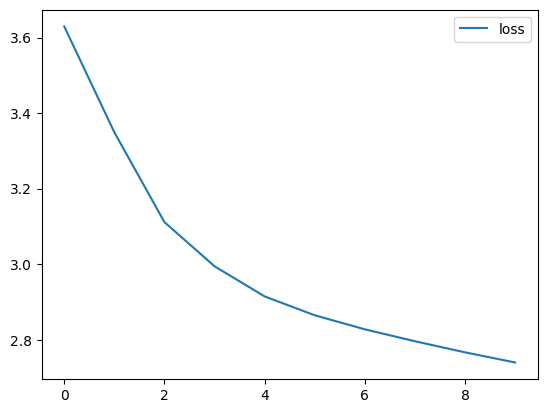

In [18]:
pd.DataFrame(h.history).plot()